# LiteLLM /response API

* [/responses](https://docs.litellm.ai/docs/response_api)

> LiteLLM provides an endpoint in the spec of [OpenAI's /responses API](https://docs.litellm.ai/docs/response_api).


* [LiteLLM - Getting Started](https://docs.litellm.ai/docs/)
* [LiteLLM Cookbook](https://github.com/BerriAI/litellm/tree/main/cookbook)

# Setup

In [1]:
%%html
<style>
table {float:left}
</style>

In [2]:
import os
import json
import operator
from datetime import datetime, timedelta, timezone
from typing import (
    List, Dict, Any, Literal, Optional, Callable, Annotated
)

import regex as re
from pydantic import BaseModel, Field
from tavily import TavilyClient
from langgraph.graph import StateGraph, START, END
import litellm
import mdformat
import trafilatura
from IPython.display import Markdown, display

## API Keys

In [3]:
path_to_openai_key:str = os.path.expanduser('~/.openai/api_key')
with open(path_to_openai_key, 'r', encoding='utf-8') as file:
    os.environ["OPENAI_API_KEY"] = file.read().strip()

path_to_tavily_key:str = os.path.expanduser('~/.tavily/api_key')
with open(path_to_tavily_key, 'r', encoding='utf-8') as file:
    os.environ["TAVILY_API_KEY"] = file.read().strip()

## Models

In [4]:
MODEL: str = "openai/gpt-4o"

---
# LiteLLM Facade - Response API

LiteLLM supports the OpenAI **Response API** via `litellm.responses()`.

| Concept | Chat Completion (deprecated) | Response API (current) |
|---|---|---|
| LiteLLM call | `litellm.completion()` | `litellm.responses()` |
| Input key | `messages=` | `input=` |
| System prompt | First message with `role="system"` | `instructions=` param |
| Tool definition | Nested `{"function": {name, desc, params}}` | Flat `{name, desc, params}` |
| Tool call location | `choices[0].message.tool_calls` | `response.output` items (`type=="function_call"`) |
| Tool call ID field | `tool_call_id` | `call_id` |
| Tool result format | `role="tool"` + `content=` | `type="function_call_output"` + `output=` |
| Final text | `choices[0].message.content` | `response.output_text` |

* [LiteLLM - Response API](https://docs.litellm.ai/docs/providers/openai/responses_api)
* [OpenAI - Migrate to Responses API](https://developers.openai.com/api/docs/guides/migrate-to-responses)


In [5]:
def call_llm(
    input: List[Any],                              # Chat Completion: messages= (List[Dict] with role/content)
                                                   # Response API:    input= (string OR List of input items)
    tools: Optional[List[Dict[str, Any]]] = None,
    stream: bool = False,
    model: str = MODEL,
    instructions: Optional[str] = None,            # Response API: replaces {"role":"system"} in messages
                                                   # Ref: https://developers.openai.com/api/reference/resources/responses/methods/create
):
    # Chat Completion (deprecated):
    #   litellm.completion(model, messages, tools, stream)
    #   Returns: ChatCompletion -> response.choices[0].message.content / .tool_calls
    #   Ref: https://developers.openai.com/api/reference/resources/chat/subresources/completions/methods/create
    #
    # Response API:
    #   litellm.responses(model, input, tools, stream, instructions)
    #   Returns: Response -> response.output (typed Items list), response.output_text (helper)
    #   Ref: https://docs.litellm.ai/docs/providers/openai/responses_api
    try:
        response = litellm.responses(
            model=model,
            input=input,
            tools=tools,
            stream=stream,
            instructions=instructions,
        )
        return response
    except litellm.AuthenticationError as e:
        raise RuntimeError(f"Authentication failed: {e}") from e
    except litellm.RateLimitError as e:
        raise RuntimeError(f"Rate limited: {e}") from e
    except litellm.APIError as e:
        raise RuntimeError(f"API error: {e}") from e


## Batch

In constrat to **streaming**, send a one-off request to get one-off reply.

In [6]:
response = call_llm(input=[{
    "role": "user",
    "content": "Hello, how are you?"
}])
# Response API:    response.output_text  (convenience helper)
# Chat Completion: response.choices[0].message.content
print(response.output_text)
print(json.dumps(response.model_dump(), indent=4, default=str))
del response


Hello! I'm just a bunch of code, but I'm here to help you. How can I assist you today?
{
    "id": "resp_bGl0ZWxsbTpjdXN0b21fbGxtX3Byb3ZpZGVyOm9wZW5haTttb2RlbF9pZDpOb25lO3Jlc3BvbnNlX2lkOnJlc3BfMDY2ZjE4OWE3YWJhMmFlODAwNjlkMGIwNDVmMTYwODE5ZjkxNWU2ZTBiMjhjYTNhNzI=",
    "created_at": 1775284293,
    "error": null,
    "incomplete_details": null,
    "instructions": null,
    "metadata": {},
    "model": "gpt-4o-2024-08-06",
    "object": "response",
    "output": [
        {
            "id": "msg_066f189a7aba2ae80069d0b0470804819f9242d6996dbbcc46",
            "content": [
                {
                    "annotations": [],
                    "text": "Hello! I'm just a bunch of code, but I'm here to help you. How can I assist you today?",
                    "type": "output_text",
                    "logprobs": []
                }
            ],
            "role": "assistant",
            "status": "completed",
            "type": "message",
            "phase": null
        }
 

## Streaming

In [7]:
response = call_llm(
    input=[{"role": "user", "content": "Hello, how are you?"}],
    stream=True
)

# Response API streaming: event-driven with typed events
# Chat Completion streaming: chunk.choices[0].delta.content
# Ref: https://docs.litellm.ai/docs/providers/openai/responses_api#streaming
for event in response:
    # Response API:    event.type == 'response.output_text.delta'  ->  event.delta
    # Chat Completion: chunk.choices[0].delta.content
    if event.type == 'response.output_text.delta':
        print(event.delta, end="", flush=True)

print()
del response


Hello

!

 I'm

 here

 and

...

 assist

 you

 today

?

/Users/oonisim/venv/llm/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `ResponseAPIUsage` - serialized value may not be as expected [field_name='usage', input_value={'completion_tokens': 17,..., 'image_tokens': None}}, input_type=dict])
  return self.__pydantic_serializer__.to_python(


---
# Tool Calling Protocol


## OpenAI API Specification


OpenAI defined the **Function (Tool) Calling Protocol** as in [Function calling](https://developers.openai.com/api/docs/guides/function-calling). 

  1. LLM responds with role: "assistant" message containing tool_calls (with id, function.name, function.arguments)
  2. You execute the tools                                                      
  3. You send back one message per tool call with role: "tool", tool_call_id matching the original id, and content containing the result as a string

There are six stages in the Protocol.

1. Tool Definition by Application and Declaration to LLM at Prompt Message
> When we make an API request to the model with a prompt, we can include a list of tools the model could consider using.

2. Tool Call Decision by LLM  (**Reasoing** and **Decisoning**)
> tool call refers to a special kind of decision response from LLM to call one of the tools to execute the prompt given.
   
3. Tool Execution by Application
4. Tool Output Usage by LLM
> tool call output refers to the response a tool generates using the input from a model’s tool call. We send **all of the tool definition, the original prompt, the model’s tool call, and the tool call output back** to LLM to finally receive a text response.

5. LLM completes the prompt

### Tool Calling Workflow

```
1. Application to LLM
   │ Define and Declare Tools in the prompt
   ▼
2. LLM
   │ Reason/Decide Tool Calls
   ▼
3. Application/Orchestration
   │ Tool Executions
   ▼
4. LLM Receives Tool Outputs
   │ Use Tool Outputs
   ▼
5. LLM Complete the prompt
```

<img src="image/tool_call_flow.png" align="left" width=500/>



## LiteLLM

Use LiteLLM as the wrapper for the OpenAI Response API for Function calling.

* [LiteLLM - Response API](https://docs.litellm.ai/docs/providers/openai/responses_api)
* [LiteLLM - Function Calling](https://docs.litellm.ai/docs/completion/function_call)

1. `litellm.responses()` with `tools=` and `instructions=`
2. Parse `response.output` for `type=="function_call"` items and execute functions
3. Second `litellm.responses()` call with tool results appended to `input`


## Tool Definition

* [Defining Functions (Tools)](https://developers.openai.com/api/docs/guides/function-calling#defining-functions)

First, you define a tool based on the OpenAI definition. This is what LiteLLM accepts as well.

| Field       | Description                                          |
|-------------|------------------------------------------------------|
| type        | This should always be function                       |
| name        | The function’s name (e.g. get_weather)               |
| description | Details on when and how to use the function          |
| parameters  | JSON schema defining the function’s input arguments  |
| strict      | Whether to enforce strict mode for the function call |


### Tool Definition Format

The tool definition format differs between Chat Completion and Response API:

**Chat Completion (deprecated)** — nested `"function"` wrapper:
```
{
  "type": "function",
  "function": {              ← extra nesting layer
     "name": "...",
     "description": "...",
     "parameters": { JSON schema }
  }
}
```

**Response API** — flat, no nested `"function"` wrapper:
```
{
  "type": "function",
  "name": "...",             ← promoted to top level
  "description": "...",
  "parameters": { JSON schema }
}
```

* [Response API - Function Calling](https://developers.openai.com/api/docs/guides/function-calling)

**Example (Response API):**
```
{
  "type": "function",
  "name": "get_weather",
  "description": "Retrieves current weather for the given location.",
  "parameters": {
    "type": "object",
    "properties": {
      "location": {
        "type": "string",
        "description": "City and country e.g. Bogota, Colombia"
      },
      "units": {
        "type": "string",
        "enum": ["celsius", "fahrenheit"],
        "description": "Units the temperature will be returned in."
      }
    },
    "required": ["location", "units"],
    "additionalProperties": false
  },
  "strict": true
}
```

### Namespace

* [Defining namespace](https://developers.openai.com/api/docs/guides/function-calling#defining-namespaces)

> Namespaces help organize similar tools and are especially useful when the model must choose between tools that serve different systems or purposes.

```
{
  "type": "namespace",
  "name": "crm",
  "description": "CRM tools for customer lookup and order management.",
  "tools": [
      tool_definition+
 ]
}
```


### Tool Parameter JSON Schema

[Pydantic JSON Schema](https://docs.pydantic.dev/latest/concepts/json_schema/) to generate the JSON Schema for the Tool Definition. 

For the Tool Definition for the [Tavilty Search](https://docs.tavily.com/sdk/python/reference#tavily-search):


#### Tool 

In [8]:
# Function for the Search Tool
search_tool: Callable = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
if not hasattr(search_tool, "tool_name"):
    search_tool.name = "search_tool"

name_to_tool: Dict[str, Callable] = {
    # search_tool.name: search_tool.search
    search_tool.name: search_tool.search
}

#### Tool Parameters

Use Pydantic to generate the JSON Schema for the parameters.

In [9]:
# Parameters for the Search Tool
class SearchToolParameters(BaseModel):
    """
    Search the web for current events, news, or deep research.
    """
    query: str = Field(description="The search query to look up")
    
    topic: Literal["general", "news", "finance"] = Field(
        default="general",
        description="Category of search. Use 'news' for current events/politics, 'finance' for market data."
    )
    
    search_depth: Literal["basic", "advanced"] = Field(
        default="basic",
        description="Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context."
    )
    
    time_range: Optional[Literal["day", "week", "month", "year"]] = Field(
        default=None,
        description="Filter results by publication date. Especially useful with topic='news'."
    )
    
    max_results: int = Field(
        default=5, ge=1, le=10,
        description="Number of search results to return."
    )

In [10]:
search_tool_parameters: Dict[str, Any] = SearchToolParameters.model_json_schema()
print(json.dumps(search_tool_parameters, indent=2, default=str))

{
  "description": "Search the web for current events, news, or deep research.",
  "properties": {
    "query": {
      "description": "The search query to look up",
      "title": "Query",
      "type": "string"
    },
    "topic": {
      "default": "general",
      "description": "Category of search. Use 'news' for current events/politics, 'finance' for market data.",
      "enum": [
        "general",
        "news",
        "finance"
      ],
      "title": "Topic",
      "type": "string"
    },
    "search_depth": {
      "default": "basic",
      "description": "Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context.",
      "enum": [
        "basic",
        "advanced"
      ],
      "title": "Search Depth",
      "type": "string"
    },
    "time_range": {
      "anyOf": [
        {
          "enum": [
            "day",
            "week",
            "month",
            "year"
          ],
          "type": "string"
        },
        {
       

#### Tool Description

In [11]:
search_tool_description: str = SearchToolParameters.__doc__.strip()
print(search_tool_description)

Search the web for current events, news, or deep research.


### Tool Definition of the Tabiliy Web Search

In [12]:
# Response API: flat tool definition (name/description/parameters at top level)
# Chat Completion: nested under "function" key -> {"type":"function","function":{"name":...}}
# Ref: https://developers.openai.com/api/docs/guides/function-calling
search_tool_definition = {
    "type": "function",
    "name": search_tool.name,                # Chat Completion: nested as "function.name"
    "description": search_tool_description,  # Chat Completion: nested as "function.description"
    "parameters": search_tool_parameters,    # Chat Completion: nested as "function.parameters"
}
print(json.dumps(search_tool_definition, indent=2, default=str))


{
  "type": "function",
  "name": "search_tool",
  "description": "Search the web for current events, news, or deep research.",
  "parameters": {
    "description": "Search the web for current events, news, or deep research.",
    "properties": {
      "query": {
        "description": "The search query to look up",
        "title": "Query",
        "type": "string"
      },
      "topic": {
        "default": "general",
        "description": "Category of search. Use 'news' for current events/politics, 'finance' for market data.",
        "enum": [
          "general",
          "news",
          "finance"
        ],
        "title": "Topic",
        "type": "string"
      },
      "search_depth": {
        "default": "basic",
        "description": "Use 'basic' for quick facts. Use 'advanced' for complex queries needing more context.",
        "enum": [
          "basic",
          "advanced"
        ],
        "title": "Search Depth",
        "type": "string"
      },
      "time_ra

## Tool Declaration

You declare the **tool definitions** to the LLM.

**Response API** — flat format:
```
tools = [
    {
      "type": "function",
      "name": "SearchTool",
      "description": "...",
      "parameters": { JSON Schema }
    },
    ...
]
```

**Chat Completion (deprecated)** — nested `"function"` wrapper:
```
tools = [
    {
      "type": "function",
      "function": {
        "name": "SearchTool",
        "description": "...",
        "parameters": { JSON Schema }
      }
    },
    ...
]
```

* [LiteLLM - Response API](https://docs.litellm.ai/docs/providers/openai/responses_api)

```python
# Response API
response = litellm.responses(
    model=model,
    input=input,
    tools=tools,            # <- declare tools here (flat format)
    instructions=instructions,
)
```

*Example input:*
```
{
  "model": "openai/gpt-4o",
  "input": [
    {
        "role": "user",
        "content": "Weather in Tokyo?"
    }
  ],
  "tools": [
    {
      "type": "function",
      "name": "get_weather",
      "parameters": {
        "type": "object",
        "properties": {
          "location": {"type": "string"}
        }
      }
    }
  ]
}
```


### Tool Declartion for the Search

In [13]:
tool_declarations: List[Dict[str, Any]] = [
    search_tool_definition
]

### Input to LLM

Build the input items to LLM (the prompt).

* Response API: `input=` takes a list of message dicts `{role, content}`
* System instructions are passed separately as `instructions=`


In [14]:
# Response API: system instructions go in the instructions= parameter (not in input items)
# Chat Completion: {"role": "system", "content": "..."} was the first element of messages
# Ref: https://developers.openai.com/api/docs/guides/migrate-to-responses#system-and-developer-messages
SYSTEM_INSTRUCTIONS: str = """
You are a helpful assistant. Use tools when needed.
Verify the relevance of retrieved results before using them, and apply an intelligent
intent filter so you keep only the news items that align with the user inquiry.
Only report items that are relevant to the user request and supported by the tool output.
If the search results are noisy or insufficient, say that and do not infer missing facts.
"""

# Response API: input= contains only user/assistant turn items (no system message)
# Chat Completion: messages= contained system + user messages together
input_prompt: List[Dict[str, str]] = [
    {
        "role": "user",      # <--- same role as before
        "content": "What are the top news headlines in AI from the last week?"
    }
]


### LLM Call


In [15]:
response_to_prompt = call_llm(
    input=input_prompt,                    # Chat Completion: messages=messages_prompt
    tools=tool_declarations,
    instructions=SYSTEM_INSTRUCTIONS,      # Chat Completion: included in messages as role="system"
)
print(json.dumps(response_to_prompt.model_dump(), indent=4, default=str))


{
    "id": "resp_bGl0ZWxsbTpjdXN0b21fbGxtX3Byb3ZpZGVyOm9wZW5haTttb2RlbF9pZDpOb25lO3Jlc3BvbnNlX2lkOnJlc3BfMGNiMmM1NjhhZjg2OTViNDAwNjlkMGIwNDk5MWJjODFhMjljNmE5NDQwZmFiNmVkN2I=",
    "created_at": 1775284297,
    "error": null,
    "incomplete_details": null,
    "instructions": "\nYou are a helpful assistant. Use tools when needed.\nVerify the relevance of retrieved results before using them, and apply an intelligent\nintent filter so you keep only the news items that align with the user inquiry.\nOnly report items that are relevant to the user request and supported by the tool output.\nIf the search results are noisy or insufficient, say that and do not infer missing facts.\n",
    "metadata": {},
    "model": "gpt-4o-2024-08-06",
    "object": "response",
    "output": [
        {
            "arguments": "{\"query\":\"AI news\",\"topic\":\"news\",\"search_depth\":\"basic\",\"time_range\":\"week\",\"max_results\":5}",
            "call_id": "call_v1Tp3iQcACniaip22Guq5Gi2",
           

## LLM Tool Calls

### Tool call handling logic

* [OpenAI - Handling function calls](https://developers.openai.com/api/docs/guides/function-calling#handling-function-calls)

**Response API** — tool calls are Items in `response.output` with `type == "function_call"`:

```python
for item in response.output:
    if item.type != "function_call":
        continue
    name = item.name
    args = json.loads(item.arguments)
    result = call_function(name, args)
    input_items.append({
        "type": "function_call_output",  # <- NOT role="tool"
        "call_id": item.id,              # <- NOT tool_call_id
        "output": str(result)            # <- NOT content
    })
```

**Chat Completion (deprecated)** — tool calls in `response.choices[0].message.tool_calls`:
```python
for tool_call in response.choices[0].message.tool_calls:
    # tool_call.id, tool_call.function.name, tool_call.function.arguments
    messages.append({"role": "tool", "tool_call_id": tool_call.id, "content": result})
```


### Tool Calls

**Response API**: the tool call is a top-level Item in `response.output`:

```
{
  "type": "function_call",
  "id": "call_JVHGxhAhxbmAlwiDkuc7fXk6",    <- call_id (used in function_call_output)
  "name": "search_tool",
  "arguments": "{\"query\":\"AI news\",\"topic\":\"news\",\"search_depth\":\"basic\"}"
}
```

**Chat Completion (deprecated)** wrapped this inside `choices[0].message.tool_calls`:
```
"message": {
    "role": "assistant",
    "tool_calls": [
        {
            "id": "call_JVHGxhAhxbmAlwiDkuc7fXk6",  <- tool_call_id
            "type": "function",
            "function": {
                "name": "search_tool",
                "arguments": "{\"query\":\"AI news\",...}"
            }
        }
    ]
}
```


In [16]:
# Response API: check response.output is non-empty
# Chat Completion: checked "choices" in response.model_dump()
assert response_to_prompt.output, \
    f"Expected non-empty output:\n{json.dumps(response_to_prompt.model_dump(), indent=2, default=str)}"


In [17]:
def extract_tool_calls(response) -> List[Any]:
    """Extract function_call items from a Response API response.

    Response API: tool calls are Items in response.output with type == "function_call"
      Each item has: .type, .id (call_id), .name, .arguments (JSON string)
      Ref: https://developers.openai.com/api/docs/guides/function-calling#handling-function-calls

    Chat Completion equivalent:
      response.choices[0].message.tool_calls
      Each: .id, .function.name, .function.arguments
    """
    return [item for item in response.output if item.type == "function_call"]


In [18]:
def in_time_window(result: Dict[str, Any], query: str, now: datetime) -> bool:
    """Return True when the result was published within the last month."""
    del query  # Reserved for query-aware time parsing later.
    published_date = result.get("published_date")
    if not published_date:
        return False
    try:
        published_at = datetime.strptime(
            published_date, "%a, %d %b %Y %H:%M:%S %Z"
        ).replace(tzinfo=timezone.utc)
    except ValueError:
        return False
    return published_at >= (now - timedelta(days=30))

def is_bad_page_type(result: Dict[str, Any]) -> bool:
    """Return True for page types that are poor RAG evidence for this tutorial."""
    negative_markers = ('/event/', 'event', 'retreat', 'viewership', '/journalism/')
    title = str(result.get("title", "")).lower()
    url = str(result.get("url", "")).lower()
    return any(marker in title or marker in url for marker in negative_markers)

def keep_result(query: str, result: Dict[str, Any], now: datetime) -> bool:
    """Return True when a Tavily result is usable for the final answer."""
    if not in_time_window(result, query, now):
        return False
    if is_bad_page_type(result):
        return False
    if float(result.get("score", 0.0)) < 0.85:
        return False
    return True

def filter_search_results(results: List[Dict[str, Any]], query: str) -> List[Dict[str, Any]]:
    """Keep only search hits that are recent, relevant, and usable."""
    now = datetime.now(timezone.utc)
    return [result for result in results if keep_result(query, result, now)]

def format_search_result(result: Dict[str, Any]) -> str:
    """Serialize one Tavily result as JSON for the tool response."""
    payload = {
        "title": result.get("title", ""),
        "url": result.get("url", ""),
        "content": result.get("content", ""),
        "published_date": result.get("published_date"),
    }
    return json.dumps(payload, ensure_ascii=False)

def execute_tool_calls(tool_calls: List[Any]) -> List[Dict[str, Any]]:
    """Execute function_call items and return function_call_output items.

    Args:
        tool_calls: function_call items from response.output
                    Each has: .type, .id, .name, .arguments (JSON string)
    Returns:
        List of function_call_output dicts for the Response API input:
        [{"type": "function_call_output", "call_id": ..., "output": ...}]

    Response API output format:
        {"type": "function_call_output", "call_id": ..., "output": ...}
    Chat Completion equivalent:
        {"role": "tool", "tool_call_id": ..., "name": ..., "content": ...}
    Ref: https://developers.openai.com/api/docs/guides/function-calling#formatting-results
    """
    _tool_outputs: List[Dict[str, Any]] = []
    for tool_call in tool_calls:
        if tool_call.type != "function_call":
            continue

        func_name: str = tool_call.name                              # Chat Completion: tool_call.function.name
        func_args: Dict[str, Any] = json.loads(tool_call.arguments)  # Chat Completion: tool_call.function.arguments
        execution: Any = name_to_tool[func_name](**func_args)
        results = execution.get("results", [])
        if func_name == "search_tool":
            results = filter_search_results(results=results, query=func_args.get("query", ""))
        if not results:
            content = json.dumps({
                "query": func_args.get("query", ""),
                "results": [],
                "note": "No clearly relevant search results were found. Ask for a narrower query or different source."
            }, ensure_ascii=False)
        else:
            content = json.dumps({
                "query": func_args.get("query", ""),
                "results": [json.loads(format_search_result(r)) for r in results]
            }, ensure_ascii=False)

        _tool_outputs.append({
            "type": "function_call_output",  # Response API (Chat Completion: no "type", role="tool")
            "call_id": tool_call.call_id,     # Response API: call_id (NOT .id which is the item ID)
            # tool_call.id = item-level ID (e.g. fc_077c...)
            # tool_call.call_id = tool call reference ID (e.g. call_abc...) -- use this
            "output": content,               # Response API: output   (Chat Completion: content)
        })

    return _tool_outputs


In [19]:
import markdown
from html.parser import HTMLParser

class _StripHTML(HTMLParser):
    """Extract plain text from HTML, used as fallback in render_content."""
    def __init__(self):
        super().__init__()
        self._parts = []
    def handle_data(self, data):
        self._parts.append(data)
    def get_text(self) -> str:
        return ''.join(self._parts)

def render_content(content: str, url: str) -> str:
    """Return clean plain text from url for display(Markdown(...)).
    Fetches original article text via trafilatura (preferred).
    Falls back to parsing the Tavily markdown snippet via the markdown
    package to strip heading/formatting artifacts.
    Args:
        content: Tavily markdown snippet (fallback source).
        url:     Original article URL (preferred source).
    """
    if url:
        downloaded = trafilatura.fetch_url(url)
        fetched = trafilatura.extract(downloaded) if downloaded else None
        if fetched:
            return fetched.replace('\xa0', ' ')
    # Fallback: markdown → HTML → strip tags → plain text
    html = markdown.markdown(content)
    extractor = _StripHTML()
    extractor.feed(html)
    return extractor.get_text().replace('\xa0', ' ')


In [20]:
def show_tool_executions(outputs: List[Dict[str, Any]]) -> None:
    """Display tool execution results.
    Parses JSON tool payloads and calls render_content(content, url)
    to fetch clean article text for display.
    """
    for msg in outputs:
        # Response API: tool result key is "output"    -> {"type":"function_call_output","call_id":...,"output":"..."}
        # Chat Completion: tool result key was "content" -> {"role":"tool","tool_call_id":...,"content":"..."}
        payload = json.loads(msg.get("output", msg.get("content", "{}")))
        results = payload.get("results", [])
        if not results:
            note = payload.get("note", "No tool results to display.")
            display(Markdown(note))
            continue
        for result in results:
            source = result.get("title", "")
            url = result.get("url", "")
            article_content = result.get("content", "")
            published_date = result.get("published_date")
            clean = render_content(content=article_content, url=url)
            header = f"**{source}**"
            if published_date:
                header += f"\n\nPublished: {published_date}"
            display(Markdown(f"{header}\n\n{clean}"))
            display(Markdown("---"))


In [21]:
tool_calls = extract_tool_calls(response=response_to_prompt)   # Chat Completion: extract_tool_call_messages
tool_outputs = execute_tool_calls(tool_calls=tool_calls)


In [22]:
show_tool_executions(outputs=tool_outputs)


**William Shatner slams AI fake news claiming he's dying, had heated Erika Kirk confrontation - Fox News**

Published: Fri, 03 Apr 2026 15:29:45 GMT

William Shatner warned fans to be skeptical of "bizarre" stories about him, adding that AI-generated fake news has been spreading on social media that he’s dying.
The "Star Trek" alum clarified that he’s "fit as a fiddle."
"I wanted to put this out yesterday but given the day and the possibility that it would look like a joke I waited for today," Shatner wrote on his Instagram page on Thursday. "There is a page on @facebook that is using AI to create horrible fake news stories about me."
Shatner said the page is known as The Beanstalk Functions Group, which he said appeared to be an event planner in South Africa.
WILLIAM SHATNER TURNS 95 AND GIVES BLUNT LIFE ADVICE THAT KEEPS HIM 'SMOKIN'!'
"They have created stories that say I have stage 4 brain cancer, was in some kind of fight with Erika Kirk and that I’m dying," he continued. "All their stories are monetized. Most of the stories use an AI image of me. Facebook Support will not remove the page."
Facebook told Fox News Digital on Thursday that the page had been removed for "violating our policies."
LIKE WHAT YOU’RE READING? CLICK HERE FOR MORE ENTERTAINMENT NEWS
Shatner added, "Each story is accompanied by a website link in the post that is hosted on Next.js where some of you may have seen my post to the CEO of that company on X asking him to remove these fake stories. None of these stories are true but they apparently seem genuine enough for fans to repost them across social media and send messages of support to me and my family all while the culprits behind the account make money," he wrote, adding that this shows the "downside of AI and yellow journalism."
CLICK HERE TO SIGN UP FOR THE ENTERTAINMENT NEWSLETTER
He wrote that while AI "can be a wonderful tool in the right hands; it can be used as a weapon in the wrong hands," urging fans to be skeptical of "bizarre" stories about him.
CLICK HERE TO DOWNLOAD THE FOX NEWS APP
A couple of hours later, Shatner shared a photo of himself smiling in a patio chair, saying that his daughter told him his granddaughter had heard he had brain cancer.
"She took this photo and sent it to me to upload to prove I'm not ill," he wrote. "The people who are ill are those that are spreading these ridiculous stories. I'm fit as a fiddle. You don't have to worry. This is getting insane."

---

**The State of AI in Automotive Retail - Automotive News**

Published: Thu, 02 Apr 2026 13:00:00 GMT

Skip to main content
Publishing Partner:
Reynolds & Reynolds
Reynolds & Reynolds
The State of AI in Automotive Retail

---

**William Shatner Slams 'Bizarre' AI-Generated 'Fake News Stories' Claiming He's Dying - Yahoo News New Zealand**

Published: Thu, 02 Apr 2026 17:49:18 GMT

William Shatner Slams 'Bizarre' AI-Generated 'Fake News Stories' Claiming He's Dying
The 'Star Trek' legend is warning fans about fake Facebook posts, including one about about him feuding with Erika Kirk
NEED TO KNOW
William Shatner is calling out a Facebook page for posting "fake news stories" about him
The Star Trek legend warned fans about AI-generated stories about him that are circulating the internet
"They have created stories that say I have stage 4 brain cancer, was in some kind of fight with Erika Kirk and that I’m dying. All their stories are monetized. Most of the stories use an AI image of me," he wrote
William Shatner is asking fans to take any shocking social media posts they see about him "with a grain of salt."
The Star Trek icon, 95, called out a Facebook page that he claims is profiting off of his likeness with AI-generated photos and news stories about his well-being. On Thursday, April 2, Shatner addressed the matter on Instagram and X, slamming the page labeled "The Beanstalk Functions Group" for using his image to generate "horrible fake news stories," including one about him dying.
"I wanted to put this out yesterday but given the day and the possibility that it would look like a joke I waited for today," Shatner wrote, referring to April Fools' Day. "There is a page on Facebook that is using AI to create horrible fake news stories about me... They have created stories that say I have stage 4 brain cancer, was in some kind of fight with Erika Kirk and that I’m dying. All their stories are monetized. Most of the stories use an AI image of me."
Shatner added that he reported the page to Facebook but the platform yet to remove it. He also wrote that he got in contact with the group's apparent CEO asking him to remove the stories himself.
Related: https://people-app.onelink.me/HNIa/kz7l4cuf
PEOPLE has reached out to reps for Facebook and Meta for comment.
Shatner's screenshots of the AI-generated posts include fake stories about him "fighting cancer," being insulted by Charlie Kirk's widow, Erika, lying in a hospital bed and being diagnosed with brain cancer. "None of these stories are true but they apparently seem genuine enough for fans to repost them across social media and send messages of support to me and my family all while the culprits behind the account make money," the actor wrote. "This is the downside of AI and yellow journalism. While can be a wonderful tool in the right hands; it can be used as a weapon in the wrong hands."
He concluded, "If you see a bizarre story about me; unless you see it posted on one of my verified accounts take it with a grain of salt."
Shatner later added in follow-up posts that "you'd be surprised at how many of my 'fans' believed the images are of me," and that people have to "jump through hoops to get content pulled."
Never miss a story — sign up for PEOPLE's free daily newsletter to stay up-to-date on the best of what PEOPLE has to offer, from celebrity news to compelling human interest stories.
On March 22, Shatner celebrated his 95th birthday on social media, when he joked that he's "still smokin" in an Instagram post. In the images, Shatner could be seen puffing on a cigar and smiling in front of a sunset. "At 95, I'm still smokin'! 😝," he captioned the snaps. "I’ve learned two things: Never waste a good cigar. Never trust anyone who says you should ‘act your age.’ 😉👍🏻"
The actor later confirmed to PEOPLE that he celebrated his big day with a "large family gathering." He previously opened up to PEOPLE about his his heartfelt birthday tradition in 2024. "For the last many years, I have celebrated my birthday by working on a very successful charity called The Hollywood Charity Horse Show. We have been doing it for 35 years and raised millions of dollars for children and veterans," he said.
More in Celebrity
Shatner added that he was spending that birthday with his family in Las Vegas, saying, "It’s going to be a family experience in that wonderful, entertaining city. I’m really looking forward to it.”
Read the original article on People

---

**Tech news: Oracle expands NetSuite AI Connector Service - Accounting Today**

Published: Fri, 03 Apr 2026 13:00:00 GMT

Oracle expands NetSuite AI Connector Service; Digits launches mobile app; Daylit releases AI AR agent; and other news and updates from the accounting tech world.
Tech news: Oracle expands NetSuite AI Connector Service
Published April 3, 2026 9:00 AM
|
Updated April 3, 2026 9:00 AM
1 Min Read

---

### Entire History Back to LLM

The entire context must be sent back to LLM to continue.

**Response API**: build the next `input` by appending `response.output` items + tool results:

```python
# input = original_input + response.output + [function_call_output, ...]
input_with_tools = input_prompt + list(response.output) + tool_outputs
```

| Layer | Chat Completion | Response API |
|---|---|---|
| Original prompt | `messages` list | `input` list |
| LLM decision | `choices[0].message` dict (with `tool_calls`) | `response.output` items (`type=="function_call"`) |
| Tool results | `{"role":"tool","tool_call_id":...,"content":...}` | `{"type":"function_call_output","call_id":...,"output":...}` |

* [Incorporating results into response](https://developers.openai.com/api/docs/guides/function-calling#incorporating-results-into-response)

> After appending the results to your input, send them back to get a final response:
> ```python
> response = client.responses.create(
>     model="gpt-4.1",
>     input=input_messages,
>     tools=tools,
> )
> ```


In [23]:
# Response API: input = original_input + response.output items + function_call_output items
# response.output includes both the function_call items AND any text items from the LLM
# Chat Completion: messages = messages_prompt + [assistant_msg_with_tool_calls] + tool_result_msgs
#
# Key difference: Response API appends response.output items directly (not just the assistant message)
# Ref: https://developers.openai.com/api/docs/guides/function-calling#incorporating-results-into-response
input_with_tool_calls: List[Any] = input_prompt + list(response_to_prompt.output) + tool_outputs
response_to_tools_called = call_llm(
    input=input_with_tool_calls,
    instructions=SYSTEM_INSTRUCTIONS,
)


In [24]:
# Response API: response.output_text (convenience helper for the final text answer)
# Chat Completion: response.choices[0].message.content
print(response_to_tools_called.output_text)
print(json.dumps(response_to_tools_called.model_dump(), indent=2, default=str))


Here are some top AI-related news headlines from the past week:

1. **William Shatner Slams AI Fake News**: William Shatner has spoken out against AI-generated fake news stories falsely claiming he is dying. This has highlighted concerns about the spread of false information via AI on social media platforms. [Read more](https://www.foxnews.com/entertainment/william-shatner-slams-ai-fake-news-claiming-hes-dying-heated-erika-kirk-confrontation)

2. **State of AI in Automotive Retail**: AI is actively reshaping the automotive retail industry, impacting how dealerships operate. A survey highlighted how dealership personnel view and utilize AI currently. [Read more](https://www.autonews.com/resource_center/Reyrey/an-state-ai-automotive-retail/)

3. **Oracle Expands NetSuite AI Connector Service**: Oracle has announced new features for its NetSuite AI Connector Service, enhancing the integration of AI models with NetSuite data for improved business applications. [Read more](https://www.accou

In [25]:
del tool_calls, tool_outputs, input_with_tool_calls, response_to_tools_called


---

## LangGraph Workflow

NOTE: **messages** in the LangGraph State corresponds with the entire message history with the Tool Call messages.

LangGraph accumuates the messages exchanged and genreated in the State.

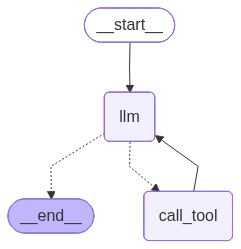

In [26]:
# Response API LangGraph: state tracks input_items (growing list of input items)
# Chat Completion LangGraph: state tracked messages (list of role/content dicts)
# Ref: https://docs.litellm.ai/docs/providers/openai/responses_api

class AgentState(BaseModel):
    # Accumulates all input items: user messages + response.output items + function_call_output items
    # Chat Completion equivalent: messages: Annotated[List[dict], operator.add]
    input_items: Annotated[List[Any], operator.add] = Field(default_factory=list)
    instructions: str = SYSTEM_INSTRUCTIONS
    # Non-accumulated flag: True when the last LLM output contained function_calls
    last_has_tool_calls: bool = False

def call_model(state: AgentState):
    """Node: call LLM, append response.output items to state."""
    response = call_llm(
        input=state.input_items,
        tools=tool_declarations,
        instructions=state.instructions,
    )
    output_items = list(response.output)
    # Response API: check output items for function_call type
    # Chat Completion: checked choices[0].message.tool_calls
    has_tool_calls = any(
        getattr(item, "type", None) == "function_call" for item in output_items
    )
    return {"input_items": output_items, "last_has_tool_calls": has_tool_calls}

def call_tool(state: AgentState):
    """Node: execute pending function_calls, append function_call_output items."""
    # Find function_call items that have no matching function_call_output yet
    processed_ids = {
        item.get("call_id")
        for item in state.input_items
        if isinstance(item, dict) and item.get("type") == "function_call_output"
    }
    pending_calls = [
        item for item in state.input_items
        if getattr(item, "type", None) == "function_call"
        and item.call_id not in processed_ids
    ]
    tool_outputs = execute_tool_calls(tool_calls=pending_calls)
    return {"input_items": tool_outputs, "last_has_tool_calls": False}

def router(state: AgentState) -> Literal["call_tool", "__end__"]:
    # Response API: route on flag set by call_model
    # Chat Completion: checked last_msg.get("tool_calls")
    return "call_tool" if state.last_has_tool_calls else "__end__"

builder = StateGraph(AgentState)
builder.add_node("llm", call_model)
builder.add_node("call_tool", call_tool)

builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", router)
builder.add_edge("call_tool", "llm")
app = builder.compile()

app


In [27]:
# Response API: initial input_items contains only user messages (system -> instructions field)
# Chat Completion: initial messages included {"role":"system",...} as first element
inputs = {
    "input_items": [
        {"role": "user", "content": "What are the top news headlines in AI from the last week?"}
    ],
    "instructions": SYSTEM_INSTRUCTIONS,
}

for event in app.stream(inputs, stream_mode="values"):
    last_item = event["input_items"][-1]

    # Determine item type -- pydantic objects from call_model, dicts from call_tool
    item_type = (
        last_item.get("type") if isinstance(last_item, dict)
        else getattr(last_item, "type", None)
    )

    if item_type == "function_call":
        # Response API: function_call item (pydantic object from response.output)
        # Chat Completion: choices[0].message.tool_calls[0].function
        func_name = last_item.name
        params = json.loads(last_item.arguments)
        print(f"\n--- LLM (Calling {func_name} with params: {params}) ---")

    elif item_type == "function_call_output":
        # Response API: function_call_output dict -> {"type":..., "call_id":..., "output":...}
        # Chat Completion: {"role":"tool", "tool_call_id":..., "content":...}
        print(f"\n--- TOOL ---")
        show_tool_executions(outputs=[last_item])

    elif item_type == "message":
        # Response API: message item with content parts (pydantic object)
        # Chat Completion: choices[0].message.content string
        content = ""
        for part in getattr(last_item, "content", []):
            if hasattr(part, "text"):
                content += part.text
            elif isinstance(part, dict):
                content += part.get("text", "")
        print(f"\n--- ASSISTANT ---")
        if content:
            print(content)
            display(Markdown(content))
        else:
            print("Processing...")

    else:
        role = (
            last_item.get("role", "unknown") if isinstance(last_item, dict)
            else getattr(last_item, "role", "unknown")
        )
        print(f"\n--- {role.upper()} ---")



--- USER ---



--- LLM (Calling search_tool with params: {'query': 'top AI news', 'topic': 'news', 'search_depth': 'basic', 'time_range': 'week', 'max_results': 5}) ---



--- TOOL ---


**Streaming Ratings: ‘Young Sherlock’ Has Solid Debut, ‘Bridgerton’ Stays On Top - TV News Check**

Published: Fri, 03 Apr 2026 09:55:27 GMT

Broadcast Industry News - Television, Cable, On-demand. Home » Streaming Ratings: ‘Young Sherlock’ Has Solid Debut, ‘Bridgerton’ Stays On Top. # Streaming Ratings: ‘Young Sherlock’ Has Solid Debut, ‘Bridgerton’ Stays On Top. Save this article for later! Don’t Miss Out on Exclusive Updates and Insights!. Subscribe to our newsletter today and unlock a world of valuable content, expert tips, and exciting updates delivered straight to your inbox. ### NewsTechForum 2025 lightning round: AI tools target workflow flexibility, first-party data & new revenue. Explore Top Media Industry Job Openings. Current job openings in the media industry, including roles in news production, digital media, management, and sales. ### NewsTECHForum Video: Storycentric Workflows & AI Help Broadcasters Meet Multiplatform Demand. Watch videoNewsTECHForum Video: Storycentric Workflows & AI Help Broadcasters Meet Multiplatform Demand. ### NewsTECHForum Video: How Broadcasters Are Operationalizing A ‘News Everywhere’ Strategy. ### NewsTECHForum Video: Media Leaders Are Finally Breaking Up With Algorithms. ### NewsTECHForum Video: AI & The New Operational Reality Of The Newsroom.

---

...

---

**AI & Tech Brief: Forecasting an AI deal - The Washington Post**

Published: Mon, 30 Mar 2026 18:53:07 GMT

AI & Tech Brief: Forecasting an AI deal - The Washington Post. *   Greg Miller Israel targets Iran’s leaders with lethal expertise using new AI platform Earlier today Image 9. Benjamin Guggenheim is the AI & Tech Brief writer for WP Intelligence at The Washington Post. *   Justin Jouvenal Trump officials cite white supremacists in bid to end birthright citizenship Today at 5:00 a.m. EDT Image 13Image 14: headline. *   Laura Meckler Protests and cancellations mar Trump administration’s America 250 tour Today at 5:00 a.m. EDT Image 17Image 18: headline. *   Dan Diamond and Jonathan Edwards Trump shows off new ballroom designs as he defends $400 million project Today at 8:26 a.m. EDT Image 21Image 22: headline. Your essential guide to AI & Tech news, published by WP Intelligence, a division of The Post focused on actionable insights for business, policy and thought leaders that operates independently from the Washington Post newsroom.

---


--- ASSISTANT ---
Here are the top AI news headlines from the past week:

1. **OpenAI Acquires TBPN**: OpenAI's acquisition of the Technology Business Programming Network marks its first foray into media. This acquisition provides OpenAI with a valuable dataset and distribution channel for AI-generated journalism and media products. [Read more](https://www.forbes.com/sites/sandycarter/2026/04/02/why-the-openai-tbpn-deal-today-is-bigger-than-anyone-is-saying/).

2. **OpenAI Raises $122 Billion**: OpenAI has raised a record $122 billion, pushing its valuation to $852 billion amid an AI boom, reflecting strong investor confidence. [Read more](https://www.tipranks.com/news/openai-raises-record-122b-pushes-valuation-to-852b-amid-ai-boom). 

These stories highlight significant developments in the AI industry, reflecting its growing influence and the strategic moves by major players like OpenAI.


Here are the top AI news headlines from the past week:

1. **OpenAI Acquires TBPN**: OpenAI's acquisition of the Technology Business Programming Network marks its first foray into media. This acquisition provides OpenAI with a valuable dataset and distribution channel for AI-generated journalism and media products. [Read more](https://www.forbes.com/sites/sandycarter/2026/04/02/why-the-openai-tbpn-deal-today-is-bigger-than-anyone-is-saying/).

2. **OpenAI Raises $122 Billion**: OpenAI has raised a record $122 billion, pushing its valuation to $852 billion amid an AI boom, reflecting strong investor confidence. [Read more](https://www.tipranks.com/news/openai-raises-record-122b-pushes-valuation-to-852b-amid-ai-boom). 

These stories highlight significant developments in the AI industry, reflecting its growing influence and the strategic moves by major players like OpenAI.